In [1]:
# first neural network with keras make predictions
from numpy import loadtxt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, Dropout, MaxPool1D, BatchNormalization, LSTM
from sklearn.model_selection import train_test_split
from tensorflow import expand_dims
import numpy as np
import tensorflow as tf
import os
import pandas as pd
import tensorflow_addons as tfa

# reproducible results functions
from numpy.random import seed
from tensorflow.compat.v1 import set_random_seed


In [2]:
# run on cpu only
os.environ["CUDA_VISIBLE_DEVICES"]="-1"   

# run on gpu
#os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
#os.environ["CUDA_VISIBLE_DEVICES"]="0"

In [3]:
# reproducible results functions seeds
seed(42)
set_random_seed(2)

In [4]:
# load the dataset
dataset = loadtxt('pima-indians-diabetes.csv', delimiter=',')
# split into input (X) and output (y) variables
X = dataset[:,0:8]
y = dataset[:,8:]

In [5]:
#mdl = 'conv1d'
#if mdl == 'conv1d':
#    X = tf.reshape(X, (X.shape[0], X.shape[1], 1)) 
#if mdl == 'lstm':
#    X = tf.reshape(X, (X.shape[0], 1, X_train.shape[1])) 

In [6]:
#def get_dataset_partitions_pd(df, train_split=0.8, val_split=0.1, test_split=0.1):
#    assert (train_split + test_split + val_split) == 1
#    
#    # Only allows for equal validation and test splits
#    assert val_split == test_split 
#
#    # Specify seed to always have the same split distribution between runs
#    df_sample = df.sample(frac=1, random_state=12)
#    indices_or_sections = [int(train_split * len(df)), int((1 - val_split - test_split) * len(df))]
#    
#    train_ds, val_ds, test_ds = np.split(df_sample, indices_or_sections)
#    
#    return train_ds, val_ds, test_ds

#train_ds, val_ds, test_ds = get_dataset_partitions_pd(pd.DataFrame(dataset), train_split=0.8, val_split=0.1, test_split=0.1)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((691, 8), (691, 1), (77, 8), (77, 1))

In [8]:
# for convnets
mdl = 'mlp'
if mdl == 'conv1d':
    X_train = tf.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1)) 
    X_test = tf.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1)) 
#    y_test = tf.reshape(y_test, (y_test.shape[0], 1))
#    y_train = tf.reshape(y_train, (y_train.shape[0], 1))
if mdl == 'lstm':
    X_train = tf.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1])) 
    X_test = tf.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1])) 
#    y_test = tf.reshape(y_test, (y_test.shape[0], 1, 1))
#    y_train = tf.reshape(y_train, (y_train.shape[0], 1, 1))

In [9]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((691, 8), (691, 1), (77, 8), (77, 1))

In [10]:
# define the keras model
def load_model(mdl='mlp'):
    model = Sequential()
    mdl = mdl.lower()
    if mdl == 'mlp' or model == None:
        model.add( Dense(32, input_shape=(X_train.shape[1], ), activation='relu') )
        model.add( Dense(16, activation='relu') )
        model.add( Dense(1, activation='sigmoid') )
    if mdl == 'conv1d':
        input_shape = (X_train.shape[1], 1)
        model.add( BatchNormalization(input_shape=input_shape) )    
        model.add( Conv1D(12, kernel_size=7, activation='relu') )        
        model.add( MaxPool1D(2) )
        model.add( Dropout(0.5) )
        model.add( Flatten() )
        model.add( Dense(y_train.shape[1], activation='sigmoid') )  
    if mdl == 'lstm':
        input_shape = (1, X_train.shape[2])
        print(input_shape)
        model.add( BatchNormalization(input_shape=input_shape) )    
        model.add( LSTM(8, go_backwards=True, activation='relu') )
        model.add( Dropout(0.5) )
        model.add( Flatten() )
        model.add( Dense(y_train.shape[1], activation='sigmoid') )        
    return model

In [11]:
# compile the keras model
model = load_model(mdl)
model.compile(loss=tf.keras.losses.BinaryCrossentropy(), 
              optimizer=tf.keras.optimizers.Adam(), 
              metrics=tf.keras.metrics.BinaryAccuracy())
model.summary()
# fit the keras model on the dataset
model.fit(X_train, y_train, epochs=150, batch_size=16, validation_split=0.1, verbose=1)

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense (Dense)                (None, 32)                288       
_________________________________________________________________
dense_1 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_2 (Dense)              (None, 1)                 17        
Total params: 833
Trainable params: 833
Non-trainable params: 0
_________________________________________________________________
Epoch 1/150
39/39 [==============================] - 1s 5ms/step - loss: 5.7157 - binary_accuracy: 0.5201 - val_loss: 1.4896 - val_binary_accuracy: 0.5857
Epoch 2/150
39/39 [==============================] - 0s 2ms/step - loss: 1.0559 - binary_accuracy: 0.6441 - val_loss: 0.6115 - val_binary_accuracy: 0.7143
Epoch 3/150
39/39 [==============================] - 0s 2ms/step - loss: 0.715

Epoch 49/150
39/39 [==============================] - 0s 2ms/step - loss: 0.6209 - binary_accuracy: 0.7440 - val_loss: 0.6028 - val_binary_accuracy: 0.7571
Epoch 50/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5780 - binary_accuracy: 0.7311 - val_loss: 0.6434 - val_binary_accuracy: 0.6857
Epoch 51/150
39/39 [==============================] - 0s 2ms/step - loss: 0.6517 - binary_accuracy: 0.7069 - val_loss: 0.5915 - val_binary_accuracy: 0.7000
Epoch 52/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5982 - binary_accuracy: 0.7069 - val_loss: 0.8822 - val_binary_accuracy: 0.6571
Epoch 53/150
39/39 [==============================] - 0s 2ms/step - loss: 0.7450 - binary_accuracy: 0.6908 - val_loss: 0.6042 - val_binary_accuracy: 0.7429
Epoch 54/150
39/39 [==============================] - 0s 1ms/step - loss: 0.5371 - binary_accuracy: 0.7246 - val_loss: 0.6474 - val_binary_accuracy: 0.7143
Epoch 55/150
39/39 [==============================] - 0s 2ms/ste

39/39 [==============================] - 0s 2ms/step - loss: 0.5435 - binary_accuracy: 0.7552 - val_loss: 0.8034 - val_binary_accuracy: 0.7286
Epoch 102/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5816 - binary_accuracy: 0.7311 - val_loss: 0.6412 - val_binary_accuracy: 0.7000
Epoch 103/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5138 - binary_accuracy: 0.7697 - val_loss: 0.6364 - val_binary_accuracy: 0.7143
Epoch 104/150
39/39 [==============================] - 0s 2ms/step - loss: 0.4880 - binary_accuracy: 0.7746 - val_loss: 0.5992 - val_binary_accuracy: 0.7571
Epoch 105/150
39/39 [==============================] - 0s 2ms/step - loss: 0.4940 - binary_accuracy: 0.7552 - val_loss: 0.6753 - val_binary_accuracy: 0.7000
Epoch 106/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5349 - binary_accuracy: 0.7343 - val_loss: 0.7078 - val_binary_accuracy: 0.7286
Epoch 107/150
39/39 [==============================] - 0s 2ms/step - los

In [12]:
float_loss, float_metric = model.evaluate(X_test, y_test)
print('loss = %.3f, precision = %.3f%%' % (float_loss, 100*float_metric))

3/3 [==============================] - 0s 2ms/step - loss: 0.5625 - binary_accuracy: 0.7403
loss = 0.563, precision = 74.026%


In [13]:
# make class predictions with the model
float_predictions = (model.predict(X_test) > 0.5).astype(int)
#predictions = predictions.squeeze()
# summarize the first 5 cases
for i in range(X_test.shape[0]):
    if mdl=='mlp':
        print('%s => %d (expected %d)' % (X_test[i], float_predictions[i], y_test[i]))        
    if mdl=='conv1d':
        print('%s => %d (expected %d)' % (X_test[i].numpy().T[0], float_predictions[i], y_test[i]))
    if mdl=='lstm':
        print('%s => %d (expected %d)' % (X_test[i].numpy().astype(int)[0], float_predictions[i], y_test[i]))

[ 2.    88.    74.    19.    53.    29.     0.229 22.   ] => 0 (expected 0)
[  0.   145.     0.     0.     0.    44.2    0.63  31.  ] => 1 (expected 1)
[ 10.    129.     62.     36.      0.     41.2     0.441  38.   ] => 1 (expected 1)
[  4.    132.      0.      0.      0.     32.9     0.302  23.   ] => 1 (expected 1)
[  5.    111.     72.     28.      0.     23.9     0.407  27.   ] => 0 (expected 0)
[  0.    107.     76.      0.      0.     45.3     0.686  24.   ] => 0 (expected 0)
[  1.    147.     94.     41.      0.     49.3     0.358  27.   ] => 0 (expected 1)
[  0.    189.    104.     25.      0.     34.3     0.435  41.   ] => 0 (expected 1)
[ 8.    91.    82.     0.     0.    35.6    0.587 68.   ] => 0 (expected 0)
[  7.    125.     86.      0.      0.     37.6     0.304  51.   ] => 1 (expected 0)
[0.00e+00 1.37e+02 6.80e+01 1.40e+01 1.48e+02 2.48e+01 1.43e-01 2.10e+01] => 0 (expected 0)
[  2.    122.     76.     27.    200.     35.9     0.483  26.   ] => 0 (expected 0)
[  7.   

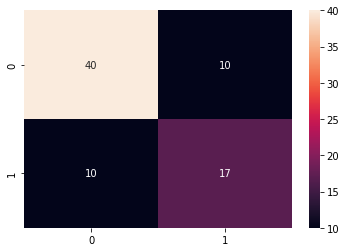

In [14]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, precision_score, recall_score, roc_auc_score
import seaborn as sns

cm = confusion_matrix(y_test, float_predictions)
sns.heatmap(cm, annot=True, fmt='g');

In [15]:
data=np.round((accuracy_score(y_test, float_predictions), precision_score(y_test, float_predictions), recall_score(y_test, float_predictions),f1_score(y_test, float_predictions), roc_auc_score(y_test, float_predictions)), 4)
pd.DataFrame(data=data, index=['acc', 'prec', 'recall', 'f1', 'auc'], columns=[f'results on {mdl}']).T

,acc,prec,recall,f1,auc
results on mlp,0.7403,0.6296,0.6296,0.6296,0.7148


#### Clone and fine-tune pre-trained model with quantization aware training

In [16]:
import tensorflow_model_optimization as tfmot

quantize_model = tfmot.quantization.keras.quantize_model

# if you want to load a model from the scratch
#model = load_model(mdl)
# q_aware stands for for quantization aware.
q_aware_model = quantize_model(model)

# `quantize_model` requires a recompile.
q_aware_model.compile(loss=tf.keras.losses.BinaryCrossentropy(), 
                      optimizer=tf.keras.optimizers.Adam(), 
                      metrics=tf.keras.metrics.BinaryAccuracy())

q_aware_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
quantize_layer (QuantizeLaye (None, 8)                 3         
_________________________________________________________________
quant_dense (QuantizeWrapper (None, 32)                293       
_________________________________________________________________
quant_dense_1 (QuantizeWrapp (None, 16)                533       
_________________________________________________________________
quant_dense_2 (QuantizeWrapp (None, 1)                 22        
Total params: 851
Trainable params: 833
Non-trainable params: 18
_________________________________________________________________


In [17]:
q_aware_model.fit(X_train, y_train, batch_size=16, epochs=150, validation_split=0.1, verbose=1)

Epoch 1/150
39/39 [==============================] - 1s 6ms/step - loss: 0.6753 - binary_accuracy: 0.6506 - val_loss: 0.6093 - val_binary_accuracy: 0.6571
Epoch 2/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5876 - binary_accuracy: 0.6699 - val_loss: 0.6312 - val_binary_accuracy: 0.6143
Epoch 3/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5572 - binary_accuracy: 0.6892 - val_loss: 0.5499 - val_binary_accuracy: 0.7286
Epoch 4/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5476 - binary_accuracy: 0.7311 - val_loss: 0.5446 - val_binary_accuracy: 0.6429
Epoch 5/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5427 - binary_accuracy: 0.7246 - val_loss: 0.5314 - val_binary_accuracy: 0.7000
Epoch 6/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5261 - binary_accuracy: 0.7343 - val_loss: 0.5708 - val_binary_accuracy: 0.7143
Epoch 7/150
39/39 [==============================] - 0s 2ms/step - los

39/39 [==============================] - 0s 2ms/step - loss: 0.6369 - binary_accuracy: 0.7504 - val_loss: 0.6617 - val_binary_accuracy: 0.7429
Epoch 54/150
39/39 [==============================] - 0s 2ms/step - loss: 0.6331 - binary_accuracy: 0.7488 - val_loss: 0.6234 - val_binary_accuracy: 0.7714
Epoch 55/150
39/39 [==============================] - 0s 2ms/step - loss: 0.8853 - binary_accuracy: 0.6812 - val_loss: 0.8070 - val_binary_accuracy: 0.6286
Epoch 56/150
39/39 [==============================] - 0s 2ms/step - loss: 0.6667 - binary_accuracy: 0.7472 - val_loss: 0.6075 - val_binary_accuracy: 0.7714
Epoch 57/150
39/39 [==============================] - 0s 2ms/step - loss: 0.6790 - binary_accuracy: 0.7327 - val_loss: 0.6076 - val_binary_accuracy: 0.7857
Epoch 58/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5996 - binary_accuracy: 0.7536 - val_loss: 0.9426 - val_binary_accuracy: 0.5714
Epoch 59/150
39/39 [==============================] - 0s 2ms/step - loss: 0.7

39/39 [==============================] - 0s 2ms/step - loss: 0.5160 - binary_accuracy: 0.7552 - val_loss: 0.7156 - val_binary_accuracy: 0.6857
Epoch 106/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5660 - binary_accuracy: 0.7488 - val_loss: 0.5362 - val_binary_accuracy: 0.8000
Epoch 107/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5101 - binary_accuracy: 0.7552 - val_loss: 0.6235 - val_binary_accuracy: 0.7286
Epoch 108/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5388 - binary_accuracy: 0.7568 - val_loss: 0.5839 - val_binary_accuracy: 0.7571
Epoch 109/150
39/39 [==============================] - 0s 2ms/step - loss: 0.5234 - binary_accuracy: 0.7729 - val_loss: 0.6104 - val_binary_accuracy: 0.7286
Epoch 110/150
39/39 [==============================] - 0s 2ms/step - loss: 0.6318 - binary_accuracy: 0.7311 - val_loss: 1.2322 - val_binary_accuracy: 0.4714
Epoch 111/150
39/39 [==============================] - 0s 2ms/step - los

In [18]:
q_loss, q_metric = q_aware_model.evaluate(X_test, y_test)
print('loss = %.3f, precision = %.3f%%' % (q_loss, 100*q_metric))

3/3 [==============================] - 0s 1ms/step - loss: 0.6475 - binary_accuracy: 0.6753
loss = 0.647, precision = 67.532%


In [19]:
# make class predictions with the model
q_predictions = (q_aware_model.predict(X_test) > 0.5).astype(int)
#predictions = predictions.squeeze()
# summarize the first 5 cases
for i in range(X_test.shape[0]):
    if mdl=='mlp':
        print('%s => %d (expected %d)' % (X_test[i], q_predictions[i], y_test[i]))        
    if mdl=='conv1d':
        print('%s => %d (expected %d)' % (X_test[i].numpy().T[0], q_predictions[i], y_test[i]))
    if mdl=='lstm':
        print('%s => %d (expected %d)' % (X_test[i].numpy().astype(int)[0], q_predictions[i], y_test[i]))

[ 2.    88.    74.    19.    53.    29.     0.229 22.   ] => 0 (expected 0)
[  0.   145.     0.     0.     0.    44.2    0.63  31.  ] => 1 (expected 1)
[ 10.    129.     62.     36.      0.     41.2     0.441  38.   ] => 1 (expected 1)
[  4.    132.      0.      0.      0.     32.9     0.302  23.   ] => 1 (expected 1)
[  5.    111.     72.     28.      0.     23.9     0.407  27.   ] => 0 (expected 0)
[  0.    107.     76.      0.      0.     45.3     0.686  24.   ] => 0 (expected 0)
[  1.    147.     94.     41.      0.     49.3     0.358  27.   ] => 0 (expected 1)
[  0.    189.    104.     25.      0.     34.3     0.435  41.   ] => 0 (expected 1)
[ 8.    91.    82.     0.     0.    35.6    0.587 68.   ] => 0 (expected 0)
[  7.    125.     86.      0.      0.     37.6     0.304  51.   ] => 1 (expected 0)
[0.00e+00 1.37e+02 6.80e+01 1.40e+01 1.48e+02 2.48e+01 1.43e-01 2.10e+01] => 1 (expected 0)
[  2.    122.     76.     27.    200.     35.9     0.483  26.   ] => 0 (expected 0)
[  7.   

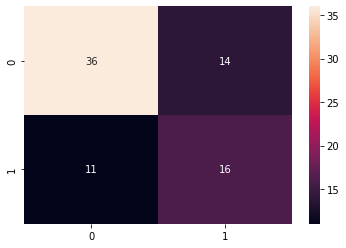

In [20]:
cm = confusion_matrix(y_test, q_predictions)
sns.heatmap(cm, annot=True, fmt='g');

In [21]:
data=np.round((accuracy_score(y_test, q_predictions), precision_score(y_test, q_predictions), recall_score(y_test, q_predictions),f1_score(y_test, q_predictions), roc_auc_score(y_test, q_predictions)), 4)
pd.DataFrame(data=data, index=['acc', 'prec', 'recall', 'f1', 'auc'], columns=[f'results on {mdl}']).T

,acc,prec,recall,f1,auc
results on mlp,0.6753,0.5333,0.5926,0.5614,0.6563


### Create a TFLiteModel for the backend

In [26]:
converter = tf.lite.TFLiteConverter.from_keras_model(q_aware_model)
converter.optimizations = [tf.lite.Optimize.OPTIMIZE_FOR_SIZE]

quantized_tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\Denys\AppData\Local\Temp\tmpdm7pexyl\assets


INFO:tensorflow:Assets written to: C:\Users\Denys\AppData\Local\Temp\tmpdm7pexyl\assets


#### See persistence of the model

In [27]:
def evaluate_model(interpreter, cut_prob=0.5):
    input_index = interpreter.get_input_details()[0]["index"]
    output_index = interpreter.get_output_details()[0]["index"]
    
    # Run predictions on every image in the "test" dataset.
    predictions = []
    for i, test_data in enumerate(X_test):
        test_data = np.expand_dims(test_data, axis=0).astype(np.float32)
        interpreter.set_tensor(input_index, test_data)

        # Run inference.
        interpreter.invoke()

        # Post-processing: remove batch dimension and find the label with highest probability
        output = interpreter.tensor(output_index)
        output = (output() > cut_prob).astype(int)
        predictions.append(output)

    print('\n')
    # Compare prediction results with ground truth labels to calculate accuracy.
    predictions = np.array(predictions)
    predictions = predictions.squeeze()
    accuracy = accuracy_score(y_test, predictions)
    return accuracy

In [28]:
interpreter = tf.lite.Interpreter(model_content=quantized_tflite_model)
interpreter.allocate_tensors()

q_accuracy = evaluate_model(interpreter, cut_prob=0.6)

print('Quant TFLite test_accuracy:', q_accuracy)
print('Quant TF test accuracy:', float_metric)



Quant TFLite test_accuracy: 0.6753246753246753
Quant TF test accuracy: 0.7402597665786743


#### Check model sizes

In [29]:
import tempfile

# Create float TFLite model.
float_converter = tf.lite.TFLiteConverter.from_keras_model(model)
float_tflite_model = float_converter.convert()

# Measure sizes of models.
_, float_file = tempfile.mkstemp('.tflite')
_, quant_file = tempfile.mkstemp('.tflite')

with open(quant_file, 'wb') as f:
    f.write(quantized_tflite_model)

with open(float_file, 'wb') as f:
    f.write(float_tflite_model)

print("Float model in Mb:", os.path.getsize(float_file) / float(2**20))
print("Quantized model in Mb:", os.path.getsize(quant_file) / float(2**20))

INFO:tensorflow:Assets written to: C:\Users\Denys\AppData\Local\Temp\tmp_f0fqrak\assets


INFO:tensorflow:Assets written to: C:\Users\Denys\AppData\Local\Temp\tmp_f0fqrak\assets


Float model in Mb: 0.004852294921875
Quantized model in Mb: 0.0037841796875
